In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
path_file = f'loan_data_total.csv'

In [7]:
df_loan = pd.read_csv(path_file, sep=';', low_memory=False)

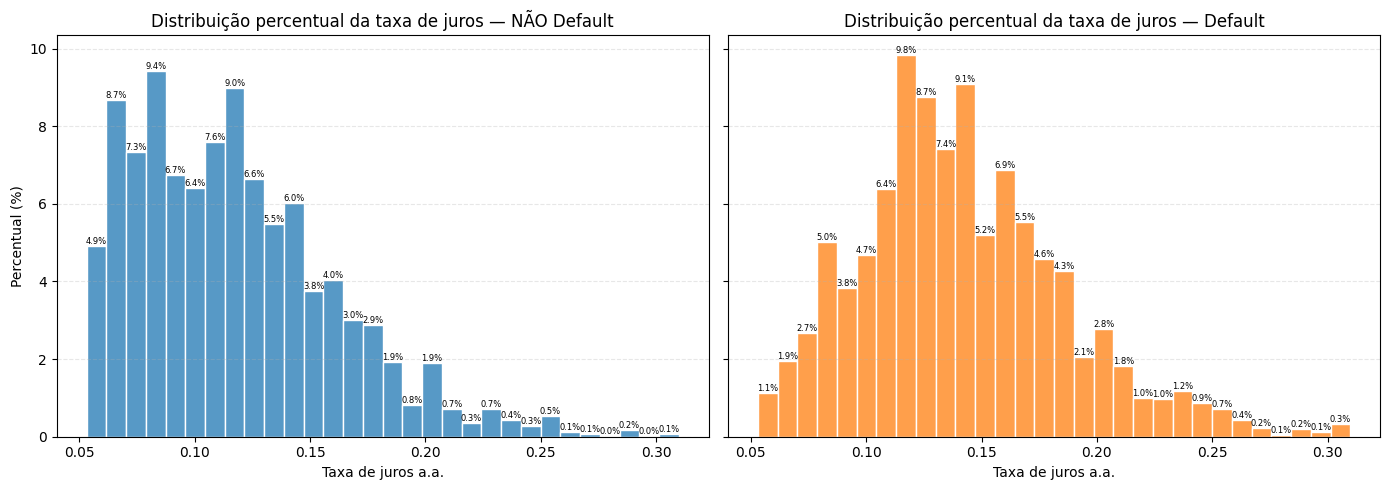

In [15]:
# =========================
# Preparação dos dados
# =========================

# Garantir que taxa_juros é numérica
df_loan['taxa_juros'] = pd.to_numeric(df_loan['taxa_juros'], errors='coerce')

taxa_nao_default = df_loan.loc[df_loan['default'] == 0, 'taxa_juros'].dropna()
taxa_default = df_loan.loc[df_loan['default'] == 1, 'taxa_juros'].dropna()

# Definir bins comuns para comparação justa
bins = np.histogram_bin_edges(
    df_loan['taxa_juros'].dropna(),
    bins=30
)

# =========================
# Gráficos
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# -------------------------
# Esquerda — NÃO Default
# -------------------------
sns.histplot(
    taxa_nao_default,
    bins=bins,
    stat='percent',
    ax=axes[0],
    color=sns.color_palette()[0],
    edgecolor='white'
)

axes[0].set_title('Distribuição percentual da taxa de juros — NÃO Default')
axes[0].set_xlabel('Taxa de juros a.a.')
axes[0].set_ylabel('Percentual (%)')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.3)

# Valores (%) sobre as barras
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(
            f'{p.get_height():.1f}%',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=6
        )

# -------------------------
# Direita — Default
# -------------------------
sns.histplot(
    taxa_default,
    bins=bins,
    stat='percent',
    ax=axes[1],
    color=sns.color_palette()[1],
    edgecolor='white'
)

axes[1].set_title('Distribuição percentual da taxa de juros — Default')
axes[1].set_xlabel('Taxa de juros a.a.')
axes[1].set_ylabel('Percentual (%)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# Valores (%) sobre as barras
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(
            f'{p.get_height():.1f}%',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=6
        )

plt.tight_layout()
plt.savefig('figuras/distribuicao_taxa_juros_default.png', dpi=600, bbox_inches='tight')
plt.show()

In [16]:
df_loan.head()

,id,data_celebracao,data_primeiro_emprestimo,data_ultimo_pagamento,valor_financiado,finalidade_emprestimo,parcelas,taxa_juros,valor_parcela,tempo_relacionamento,escore_fico,inadimplencia_2_anos,registros_publicos_negativos,renda_mensal,compm_renda,default,T
0,1077501,2011-12-01,1985-01-01,2015-01-01,5000.0,cartao de credito,36,0.1065,162.87,323,737,0,0,2000.0,0.0814,0,37
1,1077175,2011-12-01,2001-11-01,2014-06-01,2400.0,pequeno negocio,36,0.1596,84.33,121,737,0,0,1021.0,0.0826,0,30
2,1076863,2011-12-01,1996-02-01,2015-01-01,10000.0,outros,36,0.1349,339.31,190,692,0,0,4100.0,0.0828,0,37
3,1075269,2011-12-01,2004-11-01,2015-01-01,5000.0,festa de casamento,36,0.0790,156.46,85,732,0,0,3000.0,0.0522,0,37
4,1072053,2011-12-01,2007-01-01,2015-01-01,3000.0,compra de veiculo,36,0.1864,109.43,59,662,0,0,4000.0,0.0274,0,37


In [ ]:
variaveis_explicativas = ["valor_financiado", "finalidade_emprestimo", "taxa_juros", "valor_parcela", "tempo_relacionamento", "escore_fico", "inadimplencia_2anos", "registro_publicos_negativos", "renda_mensal", "compm_renda"]